In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
employee_data = {
    "EmployeeID": [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25],

    "Department": [
        "Sales","Sales","Sales","Sales","Sales",
        "Marketing","Marketing","Marketing","Marketing","Marketing",
        "Engineering","Engineering","Engineering","Engineering","Engineering",
        "HR","HR","HR","HR","HR",
        "Finance","Finance","Finance","Finance","Finance"
    ],

    "Salary": [
        62000,75000,58000,90000,130000,
        65000,72000,81000,69000,145000,
        85000,98000,110000,125000,200000,
        55000,60000,68000,72000,150000,
        70000,82000,95000,115000,175000
    ],

    "ExperienceYears": [
        2,5,1,8,12,
        3,5,7,4,15,
        2,5,7,10,20,
        1,3,5,6,22,
        2,4,7,11,18
    ],

    "HoursWorkedPerWeek": [
        42,47,50,45,60,
        40,42,44,41,55,
        43,45,48,50,65,
        38,40,42,43,35,
        44,46,48,50,58
    ],

    "PerformanceScore": [
        72,85,68,91,97,
        70,76,82,74,95,
        79,86,89,93,99,
        65,70,76,78,92,
        74,80,87,92,98
    ],

    "TrainingHours": [
        15,22,10,30,40,
        18,20,25,17,50,
        12,18,22,25,60,
        12,15,18,20,55,
        15,20,25,28,45
    ],

    "SatisfactionScore": [
        6.2,7.8,5.5,8.5,9.1,
        7.0,7.2,8.0,6.9,9.4,
        7.5,8.1,8.3,8.8,9.8,
        6.0,6.5,7.1,7.4,9.5,
        6.8,7.5,8.2,8.7,9.6
    ],

    "MonthlySales": [
        22000,35000,18000,42000,67000,
        0,0,0,0,0,
        0,0,0,0,0,
        0,0,0,0,0,
        0,0,0,0,0
    ],

    "ChurnRisk": [
        "Low","Low","High","Low","Low",
        "Medium","Medium","Low","Medium","Low",
        "Low","Low","Low","Low","Low",
        "High","Medium","Medium","Low","Low",
        "Medium","Low","Low","Low","Low"
    ]
}

#Load the data into a pandas dataFrame

In [3]:
df = pd.DataFrame(employee_data)

In [4]:
df

,EmployeeID,Department,Salary,ExperienceYears,HoursWorkedPerWeek,PerformanceScore,TrainingHours,SatisfactionScore,MonthlySales,ChurnRisk
0,1,Sales,62000,2,42,72,15,6.2,22000,Low
1,2,Sales,75000,5,47,85,22,7.8,35000,Low
2,3,Sales,58000,1,50,68,10,5.5,18000,High
3,4,Sales,90000,8,45,91,30,8.5,42000,Low
4,5,Sales,130000,12,60,97,40,9.1,67000,Low
5,6,Marketing,65000,3,40,70,18,7.0,0,Medium
6,7,Marketing,72000,5,42,76,20,7.2,0,Medium
7,8,Marketing,81000,7,44,82,25,8.0,0,Low
8,9,Marketing,69000,4,41,74,17,6.9,0,Medium
9,10,Marketing,145000,15,55,95,50,9.4,0,Low


#Create boxplots of Salary by Department

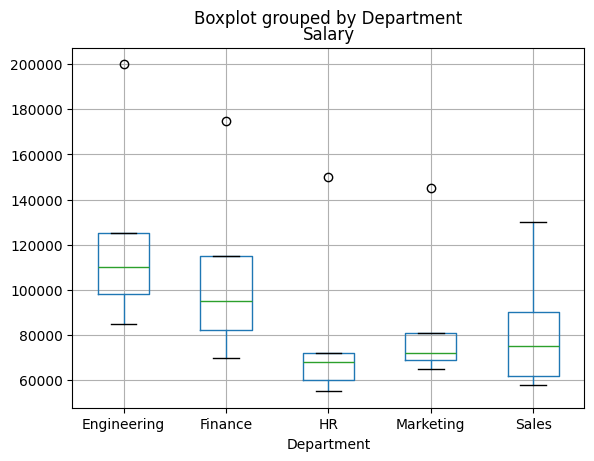

In [5]:
boxplot = df.boxplot(column="Salary", by="Department")

In [6]:
quick_statistical_summary = df.groupby("Department")['Salary'].agg(
    Q1 = lambda x: x.quantile(0.25),
    Median ='median',
    Q3 = lambda x: x.quantile(0.75))

quick_statistical_summary["IQR"] = quick_statistical_summary["Q3"] - quick_statistical_summary["Q1"]

print(quick_statistical_summary)

                  Q1    Median        Q3      IQR
Department                                       
Engineering  98000.0  110000.0  125000.0  27000.0
Finance      82000.0   95000.0  115000.0  33000.0
HR           60000.0   68000.0   72000.0  12000.0
Marketing    69000.0   72000.0   81000.0  12000.0
Sales        62000.0   75000.0   90000.0  28000.0


#Create a histogram of Performance Score

<Axes: >

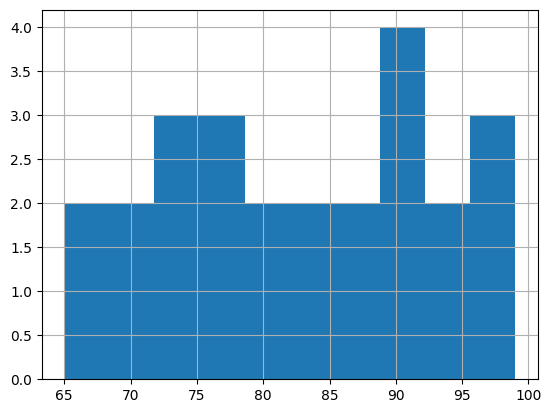

In [7]:
df['PerformanceScore'].hist()

<Axes: xlabel='PerformanceScore', ylabel='Count'>

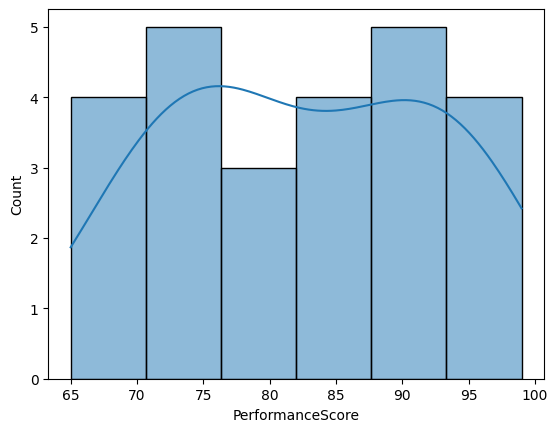

In [8]:
sns.histplot(data=df, x="PerformanceScore", kde=True)

In [9]:
df['PerformanceScore'].skew()

np.float64(0.002509680137119477)

In [10]:
print("Mean:", df["PerformanceScore"].mean())
print("Median:", df["PerformanceScore"].median())

Mean: 82.72
Median: 82.0


#Create a scatteplot -> Experience vs Salary

<Axes: xlabel='ExperienceYears', ylabel='Salary'>

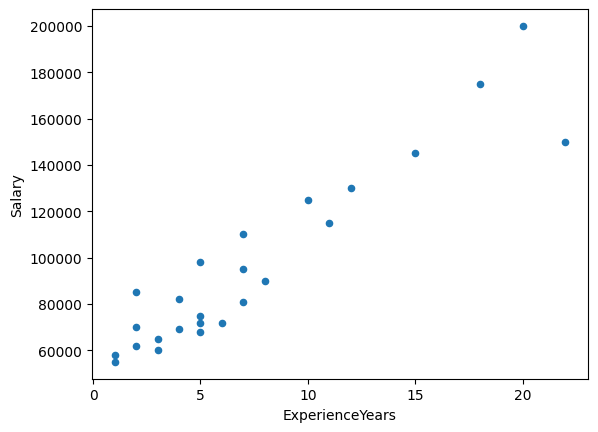

In [11]:
df.plot.scatter(x="ExperienceYears",y="Salary")

# Violin Plot — Satisfaction Score by Department

<Axes: xlabel='Department', ylabel='SatisfactionScore'>

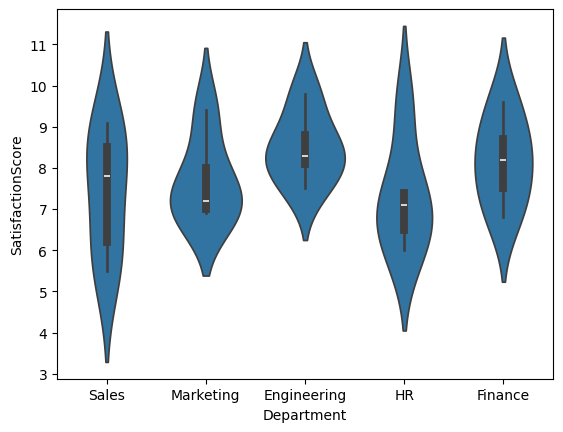

In [12]:
sns.violinplot(x=df["Department"], y=df['SatisfactionScore'])

In [13]:
df.groupby("Department")["SatisfactionScore"].describe()

,count,mean,std,min,25%,50%,75%,max
Department,,,,,,,,
Engineering,5.0,8.50,0.863134,7.5,8.1,8.3,8.8,9.8
Finance,5.0,8.16,1.078425,6.8,7.5,8.2,8.7,9.6
HR,5.0,7.30,1.343503,6.0,6.5,7.1,7.4,9.5
Marketing,5.0,7.70,1.044031,6.9,7.0,7.2,8.0,9.4
Sales,5.0,7.42,1.525451,5.5,6.2,7.8,8.5,9.1


In [16]:
numeric_cols = [
    "Salary",
    "ExperienceYears",
    "HoursWorkedPerWeek",
    "PerformanceScore",
    "TrainingHours",
    "SatisfactionScore"
]

corr_matrix = df[numeric_cols].corr()


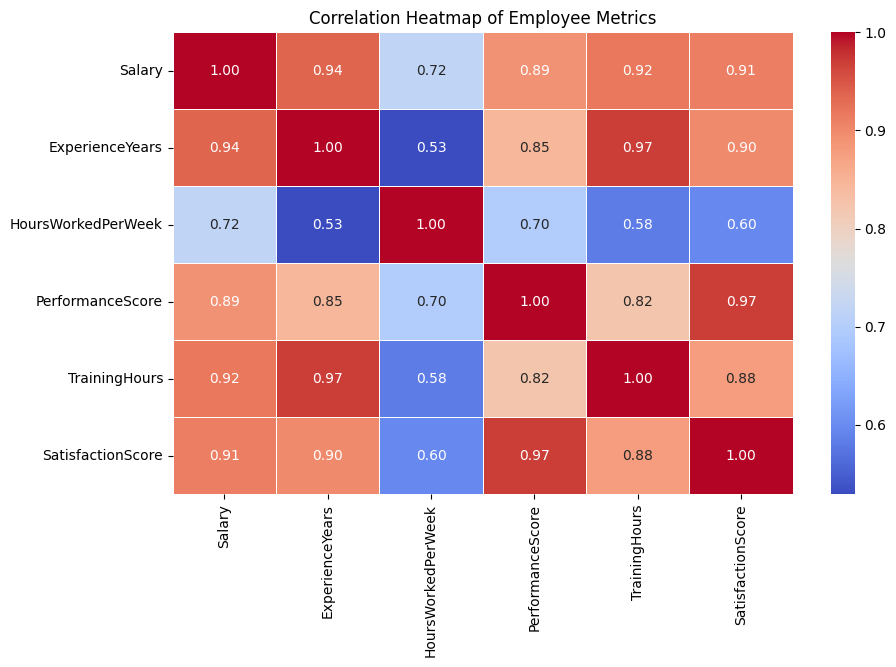

In [18]:
plt.figure(figsize=(10, 6))

sns.heatmap(corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Employee Metrics")
plt.show()